# MELTYQ Figure 8 forward comparison：実装・責務・結果の読み方

**Document status:** この日本語版をマスターとする。[English Sphinx document](../../en/meltyq/meltyq_figure8_forward_comparison_en.html) / [English notebook source](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/en/meltyq/meltyq_figure8_forward_comparison_en.ipynb) / [English RST source](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/en/meltyq/meltyq_figure8_forward_comparison_en.rst) は本書の翻訳であり、解釈が食い違う場合は日本語版を優先する。

本書は [Ito & Changeat (2026), ApJ 1006:37](https://doi.org/10.3847/1538-4357/ae6917) の Figure 8 に対して、[examples/meltyq/meltyq_figure8.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) が何を計算し、ExoFamily providerと外部dependencyがそれぞれ何を担い、結果をどこまで比較できるかを説明する。対象は**同じ表示座標を与えたforward curve comparison**であり、MELTYQ retrieval全体の再実装でも、論文数値の厳密再現でもない。

論文とその図は CC BY 4.0。本文中の論文curve値は公開vector PDFの中心線を座標化したもので、著者の未公開数値tableではない。

## 1. 実行準備とdocumentの再現性

次のcellはrepository rootを自動検出し、通常runとC/N入力基底を整合した感度runを読み込む。出力がない、計算source・installed package versionのfingerprintが一致しない、または生成済みCSV/PNGが記録済みhashと一致しない場合に生成する。通常runは `outputs/meltyq_figure8/`、基底整合runは `outputs/meltyq_figure8_basis_aligned/` に置かれる。これらは生成物なのでgit管理しない。

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if (candidate / "examples" / "meltyq" / "meltyq_figure8.py").is_file():
            return candidate
    raise RuntimeError("ExoExamples repository root was not found.")


REPO_ROOT = find_repo_root()
DOCS_DIRECTORY = REPO_ROOT / "docs" / "meltyq"
if str(DOCS_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(DOCS_DIRECTORY))

from meltyq_figure8_document_support import (
    CARBON_BASIS_FACTOR,
    NITROGEN_BASIS_FACTOR,
    FORTNEY_CORE_RADIUS_REARTH,
    PAPER_COMPOSITION_HALF_LINEWIDTH_DEX,
    PAPER_RADIUS_HALF_LINEWIDTH_REARTH,
    SPECIES,
    build_comparison,
    load_document_data,
    plot_architecture,
    plot_basis_aligned_differences,
    plot_basis_aligned_overlay,
    plot_basis_mapping_effect,
    plot_forward_curves,
    runtime_versions,
)

DATA = load_document_data(REPO_ROOT)
RAW = DATA["raw"]
ALIGNED = DATA["aligned"]
REFERENCE = DATA["reference"]
COMPARISON = build_comparison(DATA)

print(f"Repository: {REPO_ROOT}")
print(f"Executable: {sys.executable}")
print(f"Raw rows: {len(RAW)}, basis-aligned rows: {len(ALIGNED)}")
print(f"Published vector vertices: {len(REFERENCE)}")
print(
    "Generated in this execution: "
    f"raw={DATA['raw_generated']}, aligned={DATA['aligned_generated']}"
)
for label, metadata in (
    ("raw", DATA["raw_metadata"]),
    ("basis-aligned", DATA["aligned_metadata"]),
):
    provenance = metadata["document_cache"]
    print(
        f"{label} generated at {provenance['generated_at_utc']} "
        f"with fingerprint {provenance['calculation_fingerprint'][:12]}"
    )

versions = runtime_versions()
packages = ("jax", "exogibbs", "exoeos", "exojax", "exopie")
print(f"Python {versions['python']}")
for package in packages:
    print(f"{package} {versions[package]}")

Repository: /home/kawahara/exoexamples
Executable: /home/kawahara/anaconda3/envs/myenv39/bin/python
Raw rows: 77, basis-aligned rows: 77
Published vector vertices: 959
Generated in this execution: raw=True, aligned=True
raw generated at 2026-08-26T01:20:15.558857+00:00 with fingerprint 2119c377fe38
basis-aligned generated at 2026-08-26T01:20:42.409887+00:00 with fingerprint cd088d34a2b8
Python 3.9.19
jax 0.4.30
exogibbs 0.5.1.dev35+g01b21d4a7.d20260821
exoeos 0.1.1.dev29+gde99829ef
exojax 2.4.1.dev127+gcde2bda1f.d20260821
exopie 2.1.0


## 2. 責務境界とdata flow

[interface_ja.md](https://github.com/HajimeKawahara/exoexamples/blob/main/interface_ja.md) の原則は、providerが一般的な物理量を公開し、consumerがportを所有し、pair-specific adapterをconsumer側の `interop` に一つだけ置く、というものだった。このexampleはその境界を変更せず、applicationとして接続する。

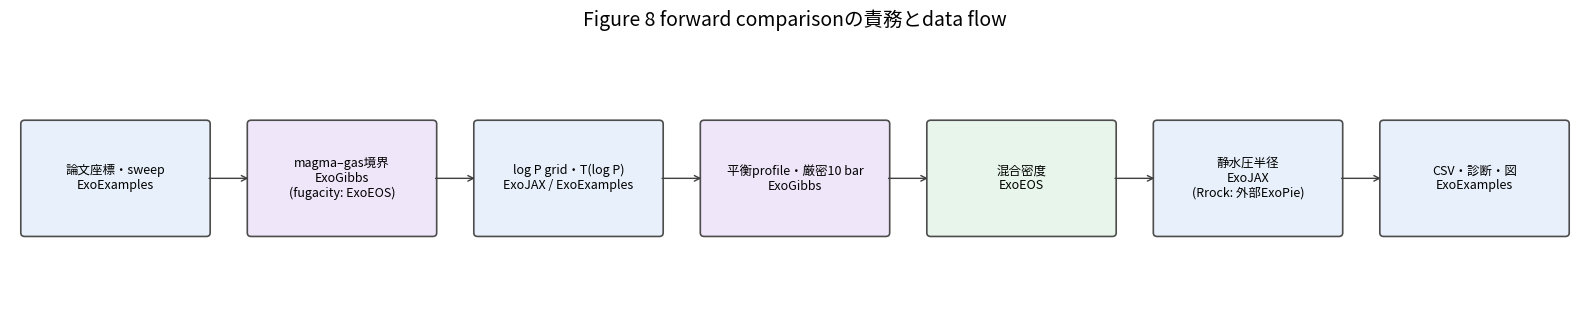

In [2]:
plot_architecture("ja")
plt.show()

| component | このworkflowでの責務 | 境界の実装 |
|---|---|---|
| [ExoGibbs](https://github.com/HajimeKawahara/exogibbs) | gas平衡、magma–gas coupling、収束診断 | `gas.solve`, `gas.solve_profile`, `magma_gas.solve` |
| [ExoEOS](https://github.com/HajimeKawahara/exoeos) | pure-component fugacity/EOS、混合密度provider | ExoGibbs所有の `exogibbs.interop.exoeos.make_pure_lnphi_func` とarray contract |
| [ExoJAX](https://github.com/HajimeKawahara/exojax) | pressure grid、静水圧半径積分、分子量 | `pressure_layer_logspace_from_boundaries`, `hydrostatic_radius_profile` |
| [ExoPie](https://github.com/mplotnyko/exopie/) | **ExoFamilyではないthird-party package**。rocky-body mass–radius gridの補間 | `get_radius` が返す岩石質下端境界のscalar radius |
| [ExoExamples](https://github.com/HajimeKawahara/exoexamples) | 物理選択、package接続、入力変換、sweep、continuation、失敗policy、CSV・図 | [meltyq_figure8.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) |

> **名前と所属に関する注意:** ExoFamily providerはExoGibbs、ExoEOS、ExoJAXである。ExoExamplesはそれらを接続するapplication repositoryであり、名前が似ているExoPieはExoFamilyの構成packageではない。ExoPieはMykhaylo Plotnykovによる外部dependencyで、そのinterior modelの方法論は [Plotnykov & Valencia (2024)](https://doi.org/10.1093/mnras/stae993)、source codeは [ExoPie GitHub repository](https://github.com/mplotnyko/exopie/) にある。

`meltyq_figure8.py` は [meltyq_clear_forward.py](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_clear_forward.py) からspecies名対応、H₂–He密度用projection、密度provider構築だけを再利用する。後者のopacity・transmission RT段は実行しない。したがって本書の“forward”は magma surface → deep atmosphere → 10 bar radius のforward mapを意味し、spectrum、cloud、retrieval posteriorは範囲外である。

### package間のunit contract

| 呼出し | 渡すunit | 戻りunit | ExoExamplesでの変換 |
|---|---|---|---|
| ExoGibbs chemistry | K; bar; dimensionless mole coordinate | mole fraction; diagnostics | 論文C/N座標だけを明示mapping |
| ExoEOS density | K; Pa; mole fraction | kg/m3 | bar to Pa: multiply by 1e5 |
| ExoJAX hydrostatic radius | bar; g/cm3; g; cm | cm | kg/m3 to g/cm3: multiply by 1e-3; Earth masses to g; Earth radii to cm |
| 外部ExoPie rocky-body radius | Earth masses; dimensionless composition | Earth radii | ExoJAXへ渡す直前にREでcm化 |

このunit変換はpackage間を接続するapplication責務である。特にExoEOS密度へbarを直接渡す、またはExoJAXへkg m$^{-3}$を直接渡すと、計算は走っても半径は物理的に誤る。

## 3. 一計算点を一本道で追う

この節では式を部品ごとに列挙するのではなく、`Figure8Parameters` の一組から最終的なplot量が出るまでをStage 0--6の順に追う。最も重要な構造は、**固定した元素量で気相平衡を解くinner solve**を、**magma--gas境界条件を満たす元素比を探すouter root**が内包する、という二重solveである。ここで「一本道」とは、一点の外部入力から一組の最終出力へ進む主経路が一つという意味であり、途中に反復がないという意味ではない。Stage 1--3はouter rootが収束するまで循環し、収束後にだけStage 4へ進む。

### 3.1 入力、未知変数、出力を先に区別する

一点ごとに外から与えるdynamic inputを

$$
\boldsymbol z=\left(P_{melt},T_{melt},f_{O_2}^{target},Q_C^{target},Q_N^{target},T_b\right)
$$

と書く。`Figure8Parameters` の `oxygen_fugacity_bar`, `co_melt_mole_ratio`, `n_melt_mole_ratio` がそれぞれ $f_{O_2}^{target},Q_C^{target},Q_N^{target}$ に対応する。上付きの `target` は実装のfield名ではなく、本書が「outer rootの収束点で計算値を一致させる、外から指定した値」を区別するために付けた記号である。**Newton法の初期値という意味ではない。**

三つのtargetは、このforward modelが仮定するmagma--gas境界条件である。

- $f_{O_2}^{target}$ はmagma surfaceの分子O₂ fugacity [bar]として指定するredox条件であり、収束時に $f_{O_2}^{gas}=f_{O_2}^{target}$ とする。またN溶解度則の $\Delta\mathrm{IW}$ をこの指定値から評価する。O atom abundanceそのものではない。
- $Q_C^{target}$ はmelt中の溶存elemental Cについて指定する希薄solute/melt-matrix mole ratioであり、収束時にtrial gasの $f_{CO}$ からC溶解度則が予測する $Q_C$ と一致させる。gasの $x_{CO}$ ではない。
- $Q_N^{target}$ はmelt中のtotal dissolved elemental Nについて指定するatomic dilute solute/melt-matrix mole ratioであり、収束時にtrial gasの $p_{N_2}$ などからN溶解度則が予測する $Q_N$ と一致させる。gasの $x_{N_2}$ ではない。

従って $Q_C^{target},Q_N^{target}$ は有限magma reservoirの総C/N inventoryでも、時間発展のinitial compositionでもない。このexampleでは「指定したmelt側濃度が、経験的溶解度則によるgasとの平衡（飽和）濃度に等しい」という条件として扱う。数値初期化は別の量 $\boldsymbol u^{(0)}$ である。初回の `initial_root(conditions)` はtarget値をheuristic seedの構築にも使うが、sweep途中では直前の収束解で置き換わる。seedを変えてもtarget条件は変わらない。

$\boldsymbol z$ から最初に求める未知量は、Hをamount-scaleのgaugeにした4個のlog元素比

$$
\boldsymbol u=\left(\ln\frac{b_C}{b_H},\ln\frac{b_O}{b_H},\ln\frac{b_N}{b_H},\ln\frac{b_{He}}{b_H}\right),\qquad
\boldsymbol b(\boldsymbol u)=(1,e^{u_C},e^{u_O},e^{u_N},e^{u_{He}})
$$

である。5元素量の共通scaleはgas mole fractionを変えないので $b_H=1$ とする。これは「水素が1 molある」という物理条件ではなく、$\boldsymbol b$ も元素mole fractionや有限reservoirの総inventoryではない。重要なのは、$\boldsymbol z\mapsto\boldsymbol u^*$ が陽な代入式ではなく、§3.5で定義する4条件を同時に満たす暗黙解

$$
\boldsymbol F(\boldsymbol z,\boldsymbol u^*)=\boldsymbol0,\qquad
\boldsymbol u^*(\boldsymbol z)=\operatorname{Root}_{\boldsymbol u}\boldsymbol F(\boldsymbol z,\boldsymbol u)
$$

だという点である。従って `z→u` の中にはStage 1--3の反復と、各残差評価に含まれるinner gas solveが畳み込まれている。用語を未知量と役割で言い換えると次のようになる。

- **inner solve:** 一つのtrial $\boldsymbol u^{(k)}$ から作った $\boldsymbol b^{(k)}$ と $T_{melt},P_{melt}$ を固定し、element balanceの下でgas Gibbs energyを最小化してspecies amount $\boldsymbol n$ とgas組成を求める。
- **outer solve:** $\boldsymbol u$ を未知量としてinner solveを繰り返し呼び、計算されたgas fugacity・溶解度から4残差を作り、それらが0になるよう元素比を更新する。melt+gas全体のGibbs最小化ではない。

固定条件は

$$
P_b=10\,\mathrm{bar},\quad h=0.84,\quad M_p=4M_\oplus,\quad
\mathrm{CMF}=0.33,\quad N_{layer}=64,\quad Y_{density}=0.275
$$

である。計算中に現れる量を混同しないため、役割を先に並べる。

| 記号 | 種類 | 意味 | 正規化・次段への役割 |
|---|---|---|---|
| $b_e$ | outer solveが決める元素量 | gas-equilibrium problemへ渡すH/C/O/N/Heのatom amount | $b_H=1$をgaugeとする。有限magma+gas reservoirの総inventoryではない |
| $n_s$ | inner solveの未知量 | 各gas speciesの非正規化amount | $A\boldsymbol n=\boldsymbol b$を満たす |
| $x_s=n_s/n_{tot}$ | inner solveの出力 | 気相mole fraction | $p_s=x_sP$, $f_s=\phi_sx_sP$を作る |
| $Y_\alpha$ | solubility lawのnative出力 | melt中のmass fractionで返る場合の溶存濃度 | speciesによってbasisが異なる |
| $Q_\alpha$ | basis変換後のmelt量 | 希薄solute/melt-matrix mole ratio | $Q_C,Q_N$だけがouter residualに入る |
| $\rho_j,r_j$ | deep-structureの未知・出力 | layer densityとpressure-boundary radius | 最終的に$R_{10\,bar}=r_0$を得る |

したがって「melt組成を入力してgas組成を一回解く」のではない。入力した $Q_C^{target},Q_N^{target}$ と、trial gasから溶解度則が予測する $Q_C,Q_N$ が一致するまで、gasへ渡す元素比そのものをouter solverが調整する。

### 3.2 Stage map：基礎方程式と実装API

| Stage | 与えられるもの | 未知量・基礎方程式 | 実際のcall | 次へ渡すもの |
|---|---|---|---|---|
| 0. problem構築 | thermochemical catalog、species、EOS | 数値未知量なし | `chemsetup` → `make_pure_lnphi_func` → `prepare_meltyq_problem` | ExoGibbs `MagmaGasProblem` |
| 1. outer trial | $\boldsymbol z$ とtrial $\boldsymbol u$ | $\boldsymbol b(\boldsymbol u)=(1,e^{u_C},e^{u_O},e^{u_N},e^{u_{He}})$ | `MeltyqMagmaGasModel.element_abundances` | trial $\boldsymbol b$ |
| 2. inner gas平衡 | $(T_{melt},P_{melt},\boldsymbol b)$ | Gibbs最小化、$A\boldsymbol n=\boldsymbol b$ | 公開入口 `magma_gas.solve` がgas-equilibrium engineを内部実行 | $\boldsymbol x,\boldsymbol p,\boldsymbol f$ |
| 3. 境界closure | gas state、target $f_{O_2},Q_C,Q_N,h$ | solubility relationsを評価し、4 residual $\boldsymbol F(\boldsymbol u)=0$ | `MeltyqMagmaGasModel.evaluate` と `magma_gas.solve` のdamped root | $\boldsymbol b^*$、surface gas、溶存濃度予測 |
| 4. deep chemistry | $\boldsymbol b^*$、指定$P_j,T_j$ | 各層で同じgas Gibbs平衡 | `gas.solve_profile`; endpointは `gas.solve` | $\boldsymbol x(P_j)$ とexact 10-bar gas |
| 5. density | $\boldsymbol x(P_j),T_j,P_j$ | density-only H₂--He projectionとadditive volume | `make_density_provider(...).mass_density_tp` | $\rho(P_j)$ |
| 6. radius | $\rho(P_j),M_p,R_{rock}$ | $dP/dr=-\rho GM_p/r^2$ | 外部 `exopie.get_radius`; ExoJAX `hydrostatic_radius_profile` | $R_{10\,bar}$ |

外から見た一本のdata flowは

$$
\boldsymbol z
\longrightarrow
\left[\boldsymbol u^*(\boldsymbol z):\ \boldsymbol F(\boldsymbol z,\boldsymbol u^*)=\boldsymbol0\right]
\longrightarrow\boldsymbol b^*
\longrightarrow\left(\boldsymbol x_{surface},\boldsymbol x(P)\right)
\longrightarrow\rho(P)\longrightarrow R_{10\,bar}.
$$

ただし角括弧内は一方向の一回評価ではなく、次のfeedback loopである。

$$
\boldsymbol u^{(k)}\to\boldsymbol b^{(k)}
\xrightarrow{\mathrm{inner\ GasEq}}(\boldsymbol x^{(k)},\boldsymbol p^{(k)},\boldsymbol f^{(k)})
\xrightarrow{\mathrm{solubility}}\boldsymbol F^{(k)}
\xrightarrow{\mathrm{outer\ update}}\boldsymbol u^{(k+1)}.
$$

半径側には別枝として

$$
(M_p,\mathrm{CMF},x_{Si},x_{Fe})\xrightarrow{\text{external ExoPie}}R_{rock}
$$

が入り、最後の静水圧積分で大気側の枝と合流する。$R_{rock}$はExoFamilyの出力ではない。

### 3.3 Stage 0：ExoGibbs problemを一度だけ組み立てる

`build_context` は、まず `exogibbs.presets.fastchem4.chemsetup(silent=True)` からsource `ChemicalSetup`を得る。次にExoGibbs所有adapter `exogibbs.interop.exoeos.make_pure_lnphi_func(...)` がExoEOSのZhang--Duan EOSを `lnphi_func(T, P_bar, None)` contractへ変換する。最後に

```python
problem = prepare_meltyq_problem(
    source_setup, lnphi_func=source_lnphi, species_map=SPECIES_MAP
)
```

を呼ぶ。返る `MagmaGasProblem` は、9-speciesへ縮約した `problem.setup`、outer mapping/residualを持つ `problem.model`、非理想性を与える `problem.lnphi_func` の三つを束ねる。ここではまだ一計算点のrootは解かない。このstatic objectを全sweep点で共有するため、thermochemistry・formula matrix・EOS closureを点ごとに再構築しない。

### 3.4 Stage 1--2：outer trialから気相Gibbs平衡まで

通常のgas-only equilibriumでは $(T,P,\boldsymbol b)$ をすべて入力する。solverは元素を作ったり失ったりせず、$\boldsymbol b$に含まれるatomを許されたgas speciesへ再配分する。MELTYQ境界で通常と異なるのは、$\boldsymbol b$自体がまだ未知であり、outer rootのtrial $\boldsymbol u$から毎回作られる点である。

boundary全体のpublic callは `exogibbs.api.magma_gas.solve` である。ExoExamplesがouter loop内で `gas.solve` を手動呼出しするのではない。`magma_gas.solve` が、(1) `problem.model.element_abundances` で $\boldsymbol u\mapsto\boldsymbol b$ を行い、(2) 各outer residual評価の内部でExoGibbs gas-equilibrium engineを実行し、(3) `problem.model.evaluate` でsolubility relationと4残差を評価する。実際のcall shapeは

```python
boundary = magma_gas.solve(
    problem,
    temperature_k=temperature_melt_k,
    pressure_bar=pressure_melt_bar,
    model_inputs=MeltyqMagmaGasInputs(
        oxygen_fugacity_bar=oxygen_fugacity_target_bar,
        co_melt_mole_ratio=carbon_melt_target,
        n_melt_mole_ratio=nitrogen_melt_target,
    ),
    init=magma_gas.MagmaGasInit(root_variables=root_initial),
    options=magma_gas.MagmaGasOptions(max_iter=100),
)
```

である。`root_initial` は初回には `problem.model.initial_root(conditions)` が作るNewton seed、sweep途中では直前の収束rootであり、物理的な追加条件ではない。これはouter $\boldsymbol u$だけのwarm startである。現ExoGibbs `magma_gas.solve` はouter trial間でinner $(\ln\boldsymbol n,\ln n_{tot})$を引き継がず、各trialのinner gas solveにはdefault initializerを使う。

元素順を$(\mathrm H,\mathrm C,\mathrm O,\mathrm N,\mathrm{He})$、species順を$(\mathrm{H_2},\mathrm{He},\mathrm{O_2},\mathrm{H_2O},\mathrm{CO},\mathrm{CO_2},\mathrm{CH_4},\mathrm{N_2},\mathrm{NH_3})$とする。元素atom countを表す$5\times9$化学量論行列は

$$
A=\begin{pmatrix}
2&0&0&2&0&0&4&0&3\\
0&0&0&0&1&1&1&0&0\\
0&0&2&1&1&2&0&0&0\\
0&0&0&0&0&0&0&2&1\\
0&1&0&0&0&0&0&0&0
\end{pmatrix},\qquad \mathrm{rank}(A)=5.
$$

gas amount $n_s>0$、$n_{tot}=\sum_s n_s$、$x_s=n_s/n_{tot}$とする。概念上のinner unknownは9個の$n_s$、1個の$n_{tot}$、5個の元素Lagrange multiplier $\pi_e$の計15個である。ExoGibbsは正値性を保つため、数値的には主に $\ln n_s$ と $\ln n_{tot}$ を反復し、各stepで$\boldsymbol\pi$を求める。FastChem4 thermochemical catalogから読む無次元standard-state項を$h_s^{FC4}(T)$、pure-component fugacity coefficientを$\phi_s(T,P)$とすると、

$$
h_s^{eff}=h_s^{FC4}+\ln\phi_s,\qquad
g_s=\frac{\mu_s}{RT}=h_s^{eff}+\ln x_s+\ln\frac{P}{P^\circ},
\qquad P^\circ=1\,\mathrm{bar}.
$$

ExoGibbsのinner solveは、$A\boldsymbol n=\boldsymbol b$の下で

$$
\boldsymbol n^*=\arg\min_{\boldsymbol n>0}
\frac{G}{RT}
=\arg\min_{\boldsymbol n>0}
\sum_s n_s\left[h_s^{eff}+\ln\frac{n_s}{n_{tot}}+\ln\frac{P}{P^\circ}\right]
$$

のKKT系を解く。実装された15本の連立条件は、5本のelement balance、1本のtotal-amount定義、9本のstationarityで

$$
A\boldsymbol n=\boldsymbol b,\qquad n_{tot}=\sum_s n_s,\qquad
\boldsymbol g=A^{\mathsf T}\boldsymbol\pi.
$$

となる。inner convergenceで使う実装残差は

$$
\epsilon_{inner}^2=
\sum_s\left[n_s\{(A^{\mathsf T}\boldsymbol\pi)_s-g_s\}\right]^2
+\|A\boldsymbol n-\boldsymbol b\|_2^2
+\left(\sum_s n_s-n_{tot}\right)^2.
$$

`exogibbs.api.gas.solve` はこの一層gas-only problemのpublic aliasであり、`magma_gas.solve` のinner engineも同じGibbs minimization kernelを使う。返る `EquilibriumResult` の `n`, `ntot`, `x` がそれぞれ $\boldsymbol n,n_{tot},\boldsymbol x$である。従って$p_s=x_sP$、$f_s=\phi_sx_sP$である。$p_s$は混合気体中のpressure share、$f_s$は非理想性をchemical potentialへ入れるeffective pressureであり、理想気体なら$\phi_s=1$で$f_s=p_s$となる。

H₂/O₂/H₂O/CO/CO₂/CH₄の$\phi_s$はExoEOSのZhang--Duan pure-component EOS、He/N₂/NH₃は$\phi_s=1$を使う。これはcomposition-dependent mixture fugacity modelではない。$\mathrm{nullity}(A)=4$であり、例えば

$$
\mathrm{O_2}+2\mathrm{H_2}\rightleftharpoons2\mathrm{H_2O},\quad
2\mathrm{CO}+\mathrm{O_2}\rightleftharpoons2\mathrm{CO_2},\quad
\mathrm{CO}+3\mathrm{H_2}\rightleftharpoons\mathrm{CH_4}+\mathrm{H_2O},\quad
\mathrm{N_2}+3\mathrm{H_2}\rightleftharpoons2\mathrm{NH_3}
$$

の4反応について$\prod_s(f_s/P^\circ)^{\nu_{rs}}=K_r(T)$がKKT条件から従う。solverはこれらを別々に手書きして解くのではない。condensateとionはnetworkにないため現れない。

### 3.5 Stage 3：溶解度則とmagma--gas境界のouter root

#### 溶解度則とは何か

gasとsilicate meltが接すると、volatile speciesは気相だけでなくmeltにも溶ける。完全な二相thermodynamic modelなら両相のchemical-potential equalityとmelt activity modelを解くが、このexampleはmelt相のGibbs energyを直接最小化しない。その代わり、実験dataへfitされた経験的なconstitutive relation

$$
Q_\alpha^{sat}=\mathcal S_\alpha\!\left(T_{melt},P_{melt},p_s,f_s,\Delta\mathrm{IW},X_{oxide}\right)
$$

を使う。これが本書でいう**溶解度則（empirical equilibrium volatile-solubility relation）**である。trial gasのpartial pressure $p_s$ またはfugacity $f_s$を入力し、そのgasと平衡にあると仮定したmelt中の**飽和溶存濃度**を返す。これはdissolutionの時間変化を表すrate lawではなく、gas mole fractionそのものでも、総volatile量の保存則でもない。

lawがmass fraction $Y_\alpha$を返す場合、ExoGibbsは平均melt molar mass $\overline M_{melt}=60$ g mol$^{-1}$を用い、dilute approximation

$$
Q_\alpha=Y_\alpha\frac{\overline M_{melt}}{M_\alpha}
\simeq\frac{n_\alpha^{dissolved}}{n_{melt\ matrix}}
$$

で希薄solute/melt-matrix mole ratioへ変換する。この$Q_\alpha$は全成分を再正規化したfinite-concentration mole fractionではない。特にCO-bearing lawでは$M_\alpha=M_C$、N lawでは$M_\alpha=M_N$なので、$Q_C,Q_N$はCO/N₂分子基底ではなくelemental-C/atomic-N基底である。

| melt側の予測量 | gas側driver | ExoGibbsのlaw / basis変換 | native output | outer rootでの役割 |
|---|---|---|---|---|
| dissolved H₂ | $f_{H_2}$ [bar], $P_{melt}$ [GPa] | `h2_hirschmann2012` | H₂ mole fraction | predictionのみ |
| dissolved H₂O | $p_{H_2O}$ [Pa] | `h2o_lichtenberg2021` → `h2o_mass_fraction_to_mole_ratio` | H₂O mass fraction | predictionのみ |
| CO-bearing gasから溶けるelemental C | $f_{CO}$ [bar] | `ln_co_yoshioka2019` → `elemental_c_ln_mass_fraction_to_ln_mole_ratio` | elemental-C mass fraction | $Q_C=Q_C^{target}$ |
| dissolved CO₂ | $p_{CO_2}$ [Pa] | `co2_lichtenberg2021` → `co2_mass_fraction_to_mole_ratio` | CO₂ mass fraction | predictionのみ |
| dissolved CH₄ | $f_{CH_4}$ [GPa], $P_{melt}$ [GPa] | `ch4_ardia2013` | CH₄ mole fraction | predictionのみ |
| total dissolved elemental N | $p_{N_2}$ [GPa], $T,P,\Delta\mathrm{IW},X_{oxide}$ | `ln_n2_dasgupta2022` → `elemental_n_ln_mass_fraction_to_ln_mole_ratio` | elemental-N mass fraction | $Q_N=Q_N^{target}$ |

各lawは有限な実験範囲でcalibrateされた経験式であり、実装は範囲外入力を自動clipしない。ExoGibbs metadataが記録する代表的な$(T,P_{total})$範囲はH₂: 1673--1773 K, 0.7--3.0 GPa; H₂O: 973--1723 K, $10^{-4}$--0.8 GPa; C-from-CO: 1523--1873 K, 0.2--3.0 GPa; CO₂: 1123--1923 K, 0.01--3.0 GPa; CH₄: 1673--1723 K, 0.7--3.0 GPa; N: 1323--2600 K, $10^{-4}$--8.2 GPaである。従ってFig. 8 sweep端で数値が返ることと、そこでlawが実験的に検証済みであることは別である。

#### 4未知数を4条件で閉じる

§3.1で定義した4未知数 $\boldsymbol u$ を、target三条件とH₂--He条件の4本で閉じる。各 $\boldsymbol u$ trialで§3.4のinner equilibriumから $\boldsymbol x(\boldsymbol u)$ を得る。$P_G=10^{-4}P_{melt,bar}$、$p_{s,Pa}=10^5x_sP_{melt,bar}$、$f_{s,GPa}=10^{-4}\phi_sx_sP_{melt,bar}$とすると、実装が評価する溶存濃度は

$$
\begin{aligned}
Q_{H_2}&=f_{H_2,bar}\exp(-11.403-0.76P_G),\\
Q_{H_2O}&=1.033\times10^{-6}p_{H_2O,Pa}^{1/1.747}\frac{60}{18.01528},\\
Y_C&=10^{-7.2}f_{CO,bar}^{0.8},& Q_C&=Y_C\frac{60}{12.0107},\\
Q_{CO_2}&=1.937\times10^{-15}p_{CO_2,Pa}^{1/0.714}\frac{60}{44.0095},\\
Q_{CH_4}&=f_{CH_4,GPa}\exp(-7.63-1.9P_G).
\end{aligned}
$$

順に[Hirschmann et al. (2012)](https://doi.org/10.1016/j.epsl.2012.06.031)、[Lichtenberg et al. (2021)](https://doi.org/10.1029/2020JE006711)、[Yoshioka et al. (2019)](https://doi.org/10.1016/j.gca.2019.06.007)、[Lichtenberg et al. (2021)](https://doi.org/10.1029/2020JE006711)、[Ardia et al. (2013)](https://doi.org/10.1016/j.gca.2013.03.028)の経験則である。$Y_C$はelemental-C mass fraction、$Q_C$はそのdilute mole ratioであり、CO分子のmole fractionではない。Nについては

$$
\begin{aligned}
\Delta\mathrm{IW}&=\log_{10}\frac{f_{O_2}^{target}}{1\,\mathrm{bar}}-L_{IW}(T_{melt},P_G),\\
a&=\frac{5908\sqrt{P_G}}{T_{melt}}-1.6\Delta\mathrm{IW},\\
c&=4.67+7.11(0.56)-13.06(0.11)-120.67(0.01),\\
Y_N&=10^{-6}\left[p_{N_2,GPa}^{1/2}e^a+p_{N_2,GPa}e^c\right],&
Q_N&=Y_N\frac{60}{14.0067}.
\end{aligned}
$$

$L_{IW}$はHirschmann et al. (2021)のiron--wüstite buffer $\log_{10}f_{O_2}^{IW}$、固定値0.56/0.11/0.01はbasaltic $X_{SiO_2}/X_{Al_2O_3}/X_{TiO_2}$である。Dasgupta et al. (2022)に従う$Q_N$はtotal elemental-Nのatomic dilute ratioで、現実装のreduced termは$\sqrt{P_G}$に依存する。

一点の計算中は $\boldsymbol z$ を固定するので、以下では $\boldsymbol F(\boldsymbol z,\boldsymbol u)$ を短く $\boldsymbol F(\boldsymbol u)$ と書く。外側で実際に解く4本の無次元log residualは

$$
\boldsymbol F(\boldsymbol u)=\begin{pmatrix}
\ln(f_{O_2}^{gas}/f_{O_2}^{target})\\
\ln(Q_C/Q_C^{target})\\
\ln(Q_N/Q_N^{target})\\
\ln(x_{H_2}/x_{He})-\ln[h/(1-h)]
\end{pmatrix}=\boldsymbol0,\qquad h=0.84.
$$

四つのresidualは順にredox、melt C、melt N、H₂--He条件を表す。O/H, C/H, N/H, He/Hと概ね対応するが、gas chemistryを介して全成分がcoupleするため、各未知数を独立に一対一調整するわけではない。

実際のfeedback loopは

$$
\boldsymbol u^{(k)}\to\boldsymbol b^{(k)}
\xrightarrow{\mathrm{inner\ GasEq}}(\boldsymbol x^{(k)},\boldsymbol p^{(k)},\boldsymbol f^{(k)})
\xrightarrow{\mathcal S_\alpha}\boldsymbol Q^{(k)}
\to\boldsymbol F^{(k)}
\xrightarrow{\mathrm{damped\ Newton}}\boldsymbol u^{(k+1)}
$$

である。outer stepは $J_F\Delta\boldsymbol u=-\boldsymbol F$ をJAX autodiff Jacobianで解き、step clippingとbacktracking line searchを適用する。収束判定は $\|\boldsymbol F\|_\infty=\max_i|F_i|$ に対して行う。exampleは `MagmaGasOptions(max_iter=100)` を使い、outer toleranceは$10^{-8}$、最後のinner gas solveはtolerance $10^{-11}$・最大1000反復で監査される。

収束点では$x_{H_2}/(x_{H_2}+x_{He})=h$となり、$\boldsymbol b^*=\boldsymbol b(\boldsymbol u^*)$が得られる。入力$f_{O_2}^{target}$はO atom abundanceではなく分子O₂のfugacityであり、O/Hはrootが推定する。$\Delta\mathrm{IW}$は指定$f_{O_2}^{target}$から計算され、収束点でgas fugacityと一致する。$Q_{H_2}$、$Q_{H_2O}$、$Q_{CO_2}$、$Q_{CH_4}$は出力されるpredictionで、outer constraintではない。この二重solveはmelt+gas全体のGibbs最小化でも有限magma reservoirのbulk volatile conservationでもない。

`magma_gas.solve` の返値 `boundary` と数学量の対応は次である。

| 数学量 | ExoGibbs result path | 次の用途 |
|---|---|---|
| $\boldsymbol u^*$ | `boundary.root_variables` | continuation seed、CSV diagnostics |
| $\boldsymbol b^*$ | `boundary.element_abundances` | 全deep layerのgas equilibrium |
| surface $\boldsymbol x$ | `boundary.gas.equilibrium.x` | Figure 8 solid curve |
| $\boldsymbol p,\boldsymbol f$ | `boundary.gas.partial_pressures_bar`, `boundary.gas.fugacities_bar` | solubility lawsとdiagnostics |
| $(Q_{H_2},Q_{H_2O},Q_C,Q_{CO_2},Q_{CH_4},Q_N)$ | `boundary.model_state.melt_volatile_mole_ratios` | melt-side prediction。現`PointResult`/CSVには未保存 |
| outer/inner収束情報 | `boundary.diagnostics` | `outer_converged`, `inner_converged`, residual等 |

### 3.6 Stage 4--5：deep atmosphereのgas-only平衡と密度

magmaと接するのは下端境界だけである。ここから上ではsolubility lawもouter rootも再実行せず、収束した同じ$\boldsymbol b^*$を全層へ渡して**gas-only equilibrium**だけを解く。upper-atmosphere baseを$P_b=10$ barとし、ExoJAX `pressure_layer_logspace_from_boundaries` で$N=64$層の境界$B_j$と代表圧力$P_j$を

$$
B_j=P_b\left(\frac{P_{melt}}{P_b}\right)^{j/N},\qquad
P_j=\sqrt{B_jB_{j+1}},\qquad j=0,\ldots,N-1
$$

と置く。外から与える温度profileと各層の化学組成は

$$
T(P)=T_b+(T_{melt}-T_b)\frac{\ln(P/P_b)}{\ln(P_{melt}/P_b)},\qquad
\boldsymbol x(P)=\mathrm{GasEq}[T(P),P,\boldsymbol b^*].
$$

$\boldsymbol b^*$を高度方向に固定するが、$\boldsymbol x$は$T,P$ごとに変わる。実装は `exogibbs.api.gas.solve_profile(problem.setup, T, P, boundary.element_abundances, ..., lnphi_func=problem.lnphi_func)` と `EquilibriumOptions(method="scan_hot_from_bottom")` を使う。これは新しい物理modelではなく、同じ一層 `gas.solve` を前層の $(\ln\boldsymbol n,\ln n_{tot})$ でwarm startするschedulerである。

profileの最上層は10 barと$P_{melt}$の間の幾何中心なので、Figure 8 dotted curveには使わない。その最上層解をseedに `exogibbs.api.gas.solve(problem.setup, T_b, 10.0, boundary.element_abundances, ...)` をもう一度呼び、exact $(T_b,P_b)$ gasを得る。この$T(P)$はradiative equilibrium、convective adiabat、energy balanceの解ではない。

密度tableのcontractを満たすため、化学組成を密度評価時だけH₂--He mass fraction $Y=0.275$へ写す。

$$
m_{HHe}=x_{H_2}M_{H_2}+x_{He}M_{He},\qquad
y_{H_2}=(1-Y)\frac{m_{HHe}}{M_{H_2}},\qquad
y_{He}=Y\frac{m_{HHe}}{M_{He}},\qquad
x_s^{\rho}=\frac{y_s}{\sum_i y_i}.
$$

その他のspeciesでは$y_s=x_s$である。このprojectionはH₂+He質量を保存し、化学平衡へ戻さない。group $g$のmass fractionを

$$
W_g=\frac{\sum_{s\in g}x_s^{\rho}M_s}{\sum_i x_i^{\rho}M_i},\qquad
\frac1{\rho}=\sum_g\frac{W_g}{\rho_g(T,P)}
$$

とし、H₂--HeにはChabrier--Debras table、O₂/H₂O/CO/CO₂/CH₄にはZhang--Duan EOS、N₂/NH₃にはideal EOSを使う。ExoExamplesの `make_density_provider` がこれらをExoEOS `AdditiveVolumeCompositeDensityProvider`へまとめ、各層で `density_provider.mass_density_tp(T_j, P_j_pa, density_composition_j)` を呼ぶ。このStageは代数的EOS closureであり、新しいroot solveではない。

### 3.7 Stage 6：外部ExoPie下端境界と静水圧半径

[ExoPie](https://github.com/mplotnyko/exopie/)はExoFamily外のthird-party interior packageである。その方法論は [Plotnykov & Valencia (2024)](https://doi.org/10.1093/mnras/stae993) に記載される。`build_context` が一度だけ呼ぶ `exopie.get_radius` のrocky branchは解析的な$R\propto M^\alpha$則ではなく、SUPEREARTH interior calculationから作られた4-D gridを補間する。現在のcallは

$$
\frac{R_{rock}}{R_\oplus}=\mathcal I_{rocky}(\mathrm{CMF},M_p/M_\oplus,x_{Si}^{core},x_{Fe}^{mantle})
=\mathcal I_{rocky}(0.33,4,0,0)=1.44527308.
$$

ここでCMFはcore mass fractionであり、返値$R_{rock}$はmetal coreだけの半径ではなくcore+mantle全体のrocky-body radiusである。`wmf=None`, `amf=None`なのでwater/envelope branchは使わず、$P_{melt}$や$T_{melt}$もExoPieへ渡さない。従ってこれはmagma-ocean半径のself-consistent solveではなく、ExoExamplesが$R(P_{melt})=R_{rock}$と置く外部Dirichlet boundaryである。

この下端からExoJAX `hydrostatic_radius_profile` が

$$
\frac{dP}{dr}=-\rho(P)\frac{GM_p}{r^2},\qquad R(P_{melt})=R_{rock}
$$

を10 barまで積分する。連続形と層内一定密度の離散形はそれぞれ

$$
I_\rho=\int_{P_b}^{P_{melt}}\frac{dP}{GM_p\rho(P)},\qquad
R_{10\,bar}=\left(R_{rock}^{-1}-I_\rho\right)^{-1},
$$

$$
\frac1{r_j}=\frac1{R_{rock}}-\sum_{k=j}^{N-1}\frac{B_{k+1}-B_k}{GM_p\rho_k}.
$$

従って$g=GM_p/r^2$の半径変化は含むが、atmosphere massとself-gravityは無視する。$R_{10\,bar}$の変化はExoPieの$R_{rock}$だけでなく、温度、化学組成、EOS密度が決める$I_\rho$も含む。

### 3.8 最終出力、方程式の種類、適用範囲

一計算点が最終的に返す物理量は

$$
\boxed{\left(\boldsymbol x_{surface},\boldsymbol x_{10\,bar},R_{10\,bar}\right)}
$$

である。順に `boundary.gas.equilibrium.x`、`base_equilibrium.x`、`radius_boundaries_cm[0] / RE` に対応する。これにouter/inner/profile/baseのconvergence diagnosticsを添えて `PointResult` とCSVへ保存する。$P_{melt},T_{melt},f_{O_2}^{target},Q_C^{target},Q_N^{target},T_b$ はこのforward modelの入力であり、solverが推定する量ではない。

ここまでに使った関係はすべて同じ種類の「基礎方程式」ではない。

| 関係 | model上の種類 |
|---|---|
| $A\boldsymbol n=\boldsymbol b$ | gas内のelement conservation |
| Gibbs minimum / $\boldsymbol g=A^{\mathsf T}\boldsymbol\pi$ | gas-phase thermodynamic equilibrium |
| $Q_\alpha=\mathcal S_\alpha(\cdots)$ | 実験fitによるmelt-side constitutive closure |
| $T=T(\ln P)$ | 外から指定するprofile parameterization |
| $\rho=\rho(T,P,\boldsymbol x)$ | EOS constitutive closure |
| $dP/dr=-\rho GM_p/r^2$ | hydrostatic governing equation |
| $R_{rock}=\mathcal I_{rocky}(\cdots)$ | 外部ExoPie grid interpolation |

#### 適用範囲と含まない物理

このFigure 8 modelは局所化学平衡を仮定し、condensation/rainout、chemical kinetics、quenching、vertical mixing、photochemistry、magmaと大気の時間発展や総volatile inventoryは解かない。cloud/haze、opacity、radiative transfer、spectrum、retrievalも範囲外である。したがって、数値収束はこの条件付きmodelの解が得られたことを示すが、経験則やEOSのcalibration範囲外で物理的に検証されたことを意味しない。

## 4. Figure 8で比較する量

論文Figure 8とこのexampleの線の意味は次の通り。

- **solid:** magma surface、すなわち $P_{melt}$ における**気相**のモル分率。
- **dotted:** $P_b=10$ bar、$T_b$ における厳密なgas equilibriumのモル分率。
- **gray:** rocky radiusを下端境界として静水圧積分した10 bar半径。
- Heは化学計算とCSVに含むが、論文に合わせてplotから省く。

数式では、各species $s$についてsolid/dottedを

$$x_s^{solid}=x_s(T_{melt},P_{melt};\boldsymbol b^*),\qquad x_s^{dotted}=x_s(T_b,P_b;\boldsymbol b^*),\qquad P_b=10\,\mathrm{bar},$$

grayを$R^{gray}=R(P_b)=(R_{rock}^{-1}-I_\rho)^{-1}$と定義できる。従ってsolidは溶解量$Q_s$でなく**magma surface直上の気相**であり、grayはExoPie単独の$R_{rock}$でなく大気の静水圧厚さを加えた半径である。

> **命名上の注意:** `PointResult.melt_mole_fractions` とCSVの `x_melt_*` は、実際には `boundary.gas.equilibrium.x` である。これはmeltに溶けた組成ではなく、magma surface直上のgas組成である。本書では一貫して「$P_{melt}$ 気相」と呼ぶ。

基準点は $M_p=4M_\oplus$, $P_{melt}=10^4$ bar, $T_{melt}=3000$ K, $f_{O_2}=10^{-5}$ bar, melt CO表示値 $10^{-5}$, melt N表示値 $10^{-6}$, $T_b=1000$ K。各panelはこのうち一つだけを変える。pressure/C/N/$f_{O_2}$ はlog座標、温度はlinear座標である。論文本文はsampling点を数表で示さないため、現在のgridはvector figureから推定した。

## 5. コード構造

### 5.1 `build_context`: 点ごとに変わらないもの

[build_context](https://github.com/HajimeKawahara/exoexamples/blob/main/examples/meltyq/meltyq_figure8.py) は次を一度だけ構築する。

1. 9 species (`H2`, `He`, `O2`, `H2O`, `CO`, `CO2`, `CH4`, `N2`, `NH3`) のmolar mass。
2. H/O/C species用Zhang–Duan pure EOSと、He・N speciesをidealとするfugacity closure。
3. FastChem4 thermochemistryを9 speciesへ縮約したExoGibbs MELTYQ problem。1500/3000 K probeはproviderが完全に温度固定されていないことだけを検査し、全温度範囲の精度保証ではない。
4. density closure：H₂–HeはChabrier–Debras $Y=0.275$ table、O₂/H₂O/CO/CO₂/CH₄はZhang–Duan、N₂/NH₃はideal EOS、全体はadditive-volume law。boundary residualのdefault $x_{H_2}/(x_{H_2}+x_{He})=0.84$ は**mole比の化学条件**である。これとは別に、table contractを満たす$Y=0.275$ **mass比projection**をH₂+He質量を保存して密度評価時だけ適用し、化学組成へは戻さない。
5. 外部ExoPieによるCMF=0.33のrocky-body lower-boundary radius（metal core半径ではない）。現runでは $R_{rock}=1.44527308R_\oplus$。
6. magma–gas boundaryとdeep structureを包む二つのJIT closure。

`jax_enable_x64` はsolver array生成前に有効化される。全scalar inputとrootを同じdtypeへ揃え、deep array shapeを64 layersに固定することで、一つのcontext内のJIT specializationは各closure一つに保たれる。

### 5.2 `solve_point`: Stage 1--6のorchestrator

§3の方程式に対するcode pathは次の順で進む。

1. **magma–gas boundary:** JIT wrapper `context.solve_boundary` がpublic `exogibbs.api.magma_gas.solve` を呼ぶ。outerの各residual評価でinner gas-equilibrium engineが動き、$\boldsymbol u^*,\boldsymbol b^*$とsurface gasを返す。`outer_converged` は4-D root、`inner_converged` は最後のgas solve、`converged` は両者を合わせた判定である。CSVの `boundary_root_0..3` は $u_C,u_O,u_N,u_{He}$、`boundary_residual_0..3` はO₂ fugacity、melt C、melt N、H₂/He条件の順である。
2. **deep grid:** ExoJAX `pressure_layer_logspace_from_boundaries` で10 barから $P_{melt}$ まで64層をlog-pressureで作る。temperatureは

   $$T(P)=T_b+(T_{melt}-T_b)\frac{\log P-\log P_b}{\log P_{melt}-\log P_b}.$$

3. **vertical chemistry:** JIT wrapper `context.solve_structure` 内の `exogibbs.api.gas.solve_profile` が、$\boldsymbol b^*$を高度方向に固定して `scan_hot_from_bottom` でgas equilibrium profileを解く。
4. **exact 10 bar state:** 同wrapper内の `exogibbs.api.gas.solve` が、最上層代表点の解をseedに$(T_b,10\,bar)$ の独立な一層平衡を解く。dotted curveはこのexact stateである。
5. **density:** `density_provider.mass_density_tp` が各層の組成・$T$・Pa単位の$P$からExoEOS densityを評価し、finiteかつpositiveであることを検査する。
6. **radius:** ExoJAX `hydrostatic_radius_profile` が $R(P_{melt})=R_{rock}$ を下端条件として

   $$\frac{dP}{dr}=-\rho(P)\frac{GM_p}{r^2}$$

   を10 barまで積分する。$g\propto r^{-2}$ は含むが、atmosphere massとself-gravityは無視する。

各段で失敗した場合はNaNと診断を保存し、curveを補間して埋めない。`--allow-incomplete` は最後のexit policyを緩めるだけで、失敗値そのものは変更しない。

### 5.3 sweep、continuation、四つのcache

`run_sweeps` はまず共通baselineを解き、各panelでbaselineから低い側・高い側へ別々に進む。直前に収束した4-D rootだけを次点へ渡すため、一方向の失敗が反対方向のseedを汚染しない。6 panelに現れるbaselineはPython result cacheで共有され、77 plot rowsは72 unique parameter tuplesへ畳み込まれる。

混同しやすいcacheは四つある。

1. `ModelContext`: EOS/problem/JIT functionを共有。
2. JAX process内cache: 固定shape/dtypeに対する二つのspecialization。
3. `.cache/jax`: compatibleなXLA executableをprocess間で再利用。solver計算そのものを省くものではない。
4. `run_sweeps` のPython dictionary: 同一parameter tupleの数値結果を共有。

2026-08-24にこのhost（AMD EPYC 7452、JAX 0.4.30、CPU backend）で行った別の速度監査では、cold full run 65.16 s、別processのpersistent-cache run 19.68 s、同一contextでの全sweep再計算0.875 sだった。これはnotebook自身のbenchmarkではなく、その環境に固有の参考値である。backend・JAX version・shapeを変えれば正当な再compileが起きる。

### 5.4 data model・output・CLIのsource map

| code element | 役割 |
|---|---|
| `Figure8Parameters` / `SweepSpec` | 一点の6入力 / panel軸・grid・表示規則 |
| `ModelContext` | 全点で共有するproblem、JIT closure、rocky radius、solver options |
| `PointResult` / `SweepPoint` | 物理出力と診断 / panel上のrequested coordinateとの対応 |
| `build_context` | static provider、外部ExoPieの$R_{rock}$、二つのJIT closureを構築 |
| `solve_point` / `run_sweeps` | 一点のforward map / baseline-centered continuationとresult cache |
| `write_results_csv` / `write_metadata` | unclipped composition・全診断 / fixed condition・grid・input basis |
| `plot_results` / `main` | Figure 8形式の描画 / CLI validation・出力・失敗exit policy |

CLIは `--output-directory`, `--deep-layers`, `--max-outer-iterations`, `--allow-incomplete`, `--show` を持つ。CSVは77 panel rowsを保持するためbaselineが6回現れるが、metadataと実行logの`unique points`はresult cache後の72点を指す。

## 6. 現行same-numeric-input runの監査

In [3]:
parameter_columns = [
    "pressure_melt_bar",
    "temperature_melt_k",
    "oxygen_fugacity_bar",
    "co_melt_mole_ratio",
    "n_melt_mole_ratio",
    "temperature_base_k",
]
convergence_columns = [
    "boundary_converged",
    "boundary_outer_converged",
    "boundary_inner_converged",
    "profile_converged",
    "base_converged",
]
unique_points = len(RAW[parameter_columns].drop_duplicates())
aligned_unique_points = len(ALIGNED[parameter_columns].drop_duplicates())
raw_complete = bool(RAW[convergence_columns].all().all())
aligned_complete = bool(ALIGNED[convergence_columns].all().all())
baseline = RAW[
    (RAW["sweep"] == "pressure_melt")
    & np.isclose(RAW["sweep_value"], 1.0e4)
].iloc[0]

print(f"raw: plot rows={len(RAW)}, unique points={unique_points}")
print(
    f"basis-aligned: plot rows={len(ALIGNED)}, "
    f"unique points={aligned_unique_points}"
)
print(f"raw all convergence flags true={raw_complete}")
print(f"basis-aligned all convergence flags true={aligned_complete}")
print(
    "baseline diagnostics: "
    f"boundary iterations={baseline.boundary_iterations}, "
    f"residual norm={baseline.boundary_residual_norm:.3e}, "
    f"profile max iterations={baseline.profile_max_iterations}, "
    f"10-bar iterations={baseline.base_iterations}"
)
print(
    f"R_rock={baseline.rocky_radius_rearth:.9f} R_earth, "
    f"R_10bar={baseline.radius_base_rearth:.9f} R_earth"
)

composition_rows = []
for species in (*SPECIES, "He"):
    composition_rows.append(
        {
            "species": species,
            "P_melt gas": baseline[f"x_melt_{species}"],
            "10 bar gas": baseline[f"x_10bar_{species}"],
        }
    )
composition_table = pd.DataFrame(composition_rows)
print("\nBaseline gas composition:")
print(
    composition_table.to_string(
        index=False,
        formatters={
            "P_melt gas": lambda value: f"{value:.7e}",
            "10 bar gas": lambda value: f"{value:.7e}",
        },
    )
)

radius_ranges = RAW.groupby("sweep")["radius_base_rearth"].agg(
    ["min", "max"]
)
print("\n10-bar radius ranges [R_earth]:")
print(radius_ranges.to_string(float_format=lambda value: f"{value:.6f}"))

raw: plot rows=77, unique points=72
basis-aligned: plot rows=77, unique points=72
raw all convergence flags true=True
basis-aligned all convergence flags true=True
baseline diagnostics: boundary iterations=5, residual norm=8.882e-15, profile max iterations=4, 10-bar iterations=3
R_rock=1.445273080 R_earth, R_10bar=1.836658224 R_earth

Baseline gas composition:
species    P_melt gas    10 bar gas
     H2 7.8296103e-01 7.7997030e-01
     O2 3.9842886e-10 5.1055405e-24
    H2O 6.2075506e-02 6.4439516e-02
     CO 2.2922887e-03 1.9099757e-04
    CO2 1.9704138e-05 2.2799489e-05
    CH4 3.4570046e-03 5.5792868e-03
     N2 2.3002151e-07 2.0507128e-05
    NH3 5.8806223e-05 1.8499456e-05
     He 1.4913543e-01 1.4975810e-01

10-bar radius ranges [R_earth]:
                      min      max
sweep                             
co_melt          1.707134 1.849651
n_melt           1.820171 1.836769
oxygen_fugacity  1.508178 1.939685
pressure_melt    1.590413 2.134635
temperature_base 1.759567 1.958580

same-numeric runとbasis-aligned runの全77 rowsで、boundary outer root、最後のinner gas solve、deep profile、exact 10 barの全flagがtrueだった。したがって現在の比較差を「100反復で外側rootが収束しないため」と解釈してはいけない。plotは $10^{-10}$ で表示clipするが、CSVはclip前の値とroot/residualを保持する。実装内部のlegacy定数名 `FORTNEY_CORE_RADIUS_REARTH` もmetal core半径ではなく、比較用のrocky-body radiusを表す。

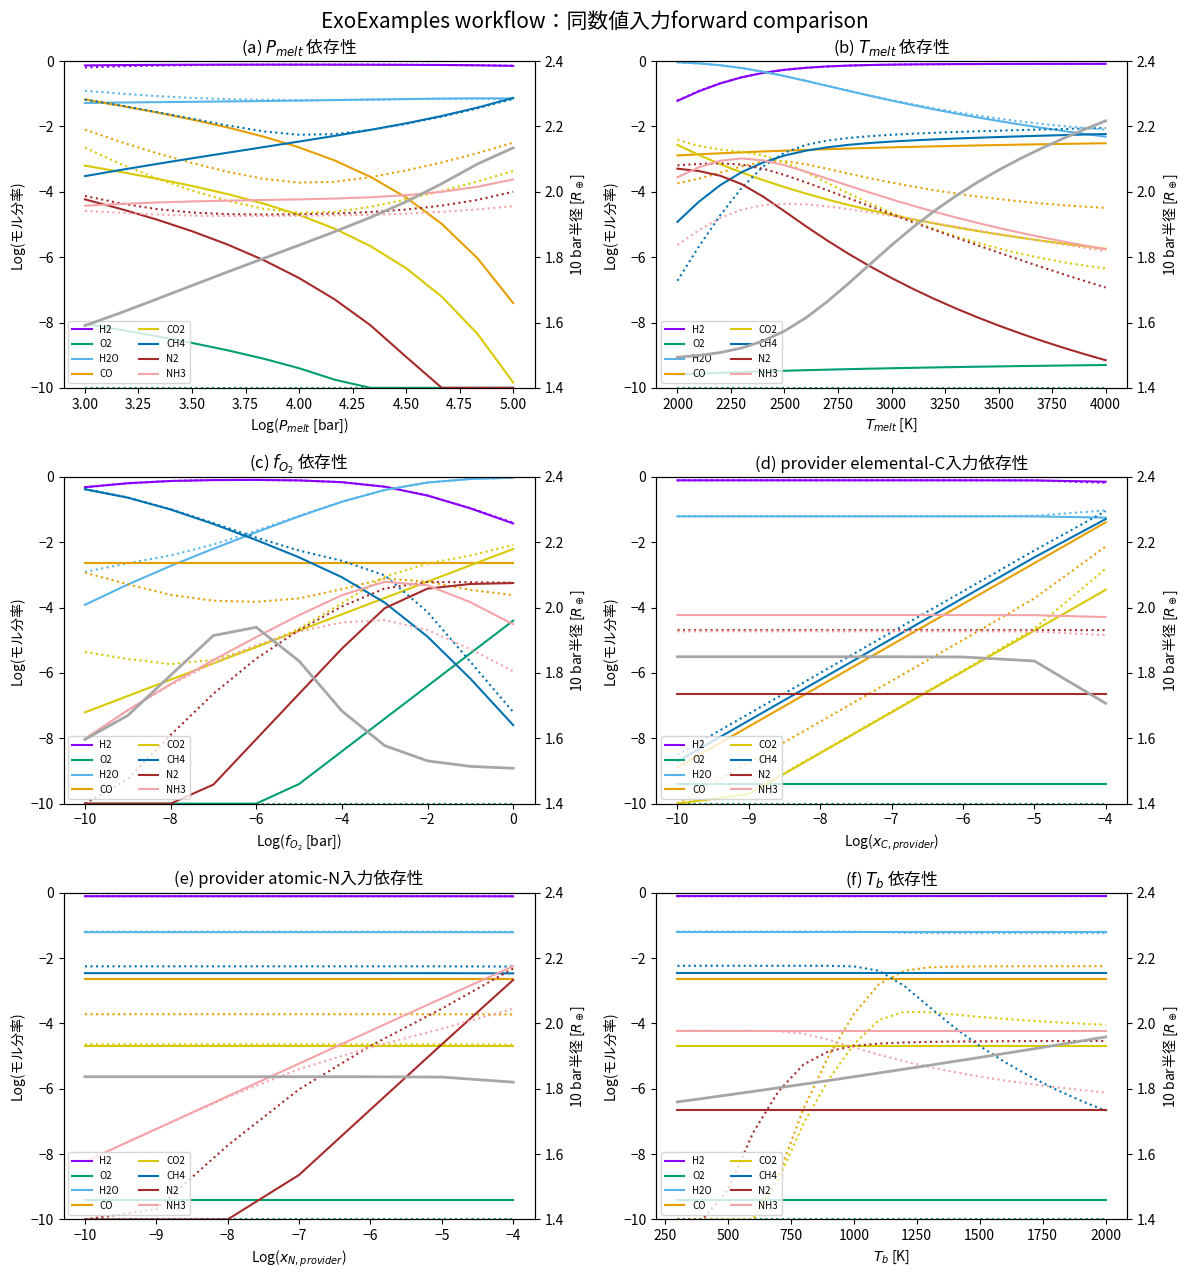

In [4]:
plot_forward_curves(RAW, language="ja")
plt.show()

上図はmain exampleが出力するsame-numeric-input runをCSVから再描画したもの。solid/dottedの大局的な形は論文Fig. 8に似る一方、C/N speciesと半径に系統offsetがある。次節では、そのうち入力定義だけで説明できる部分を切り分ける。

## 7. 論文Figure 8との比較方法

### 7.1 vector referenceの限界

論文はFigure 8の数値tableを公開していない。本書はarXiv sourceの `f8a_dep_pmelt_t.pdf` から `f8f_dep_tb_t.pdf` をSVGへ変換し、色・solid/dotted styleごとの中心線を [meltyq_figure8_vector_reference.csv](https://github.com/HajimeKawahara/exoexamples/blob/main/docs/meltyq/data/meltyq_figure8_vector_reference.csv) に保存した。縦軸外のcurveは値を決められないため比較から除外する。比較残差を

$$\Delta_s=\log_{10}x_s^{workflow}-\log_{10}x_s^{paper},\qquad \Delta_R=R_{10}^{workflow}-R_{10}^{paper}$$

と定義する。元線の半幅は座標換算で約0.03190 dex、radiusは約0.003190 $R_\oplus$ である。これは図上で中心線差を識別しにくいscaleの目安であり、統計的不確かさ・error bar・数値精度の許容値ではない。この範囲より細かな一致を“論文数値との厳密一致”とは呼ばない。

### 7.2 CO/N入力基底を明示する

MELTYQ Appendix Aはlaw outputをCO/N₂ mass fractionと記述し、平均melt molar mass 60 g mol⁻¹とmolecular massでmelt mole coordinateへ変換する。一方、一次文献とExoGibbsは対応するlaw outputをelemental-C/atomic-N mass fractionとして扱い、public inputを12.0107/14.0067 g mol⁻¹基底のdilute mole coordinateとする。著者codeは非公開なので、ここでは**同じ数値law outputをpaper-labelled座標からprovider座標へ写すoperational mapping**を仮定する：

$$x_{C,Exo}=x_{CO,paper}\frac{28.0101}{12.0107}=2.332095548\,x_{CO,paper},$$

$$x_{N,Exo}=x_{N_2,paper}\frac{28.0134}{14.0067}=2\,x_{N_2,paper}.$$

このmappingはvector curveの大幅な一致改善によって強く支持されるが、未公開author table/codeの直接確認ではない。pair-specific physics adapterではなく、paper座標をprovider contractへ写すapplication入力変換なのでExoExamplesの責務である。main exampleは変換を暗黙に行わずsame-numeric runを保存する。本書のbasis-aligned runは、paper axis (`sweep_value`) を保ったまま、providerへ渡すbaselineとC/N sweep値に上式を明示適用した感度計算である。

In [5]:
def residual_summary(frame):
    values = frame["delta"].abs()
    return {
        "n": len(values),
        "median_abs": values.median(),
        "p90_abs": values.quantile(0.90),
        "p95_abs": values.quantile(0.95),
        "max_abs": values.max(),
    }


raw_surface = COMPARISON[
    (COMPARISON["label"] == "raw")
    & (COMPARISON["endpoint"] == "surface")
    & COMPARISON["visible"]
]
raw_base = COMPARISON[
    (COMPARISON["label"] == "raw")
    & (COMPARISON["endpoint"] == "base")
    & COMPARISON["visible"]
]
aligned_clean = COMPARISON[
    (COMPARISON["label"] == "basis-aligned")
    & (COMPARISON["endpoint"] != "radius")
    & COMPARISON["visible"]
    & ~(
        (COMPARISON["sweep"] == "pressure_melt")
        & COMPARISON["species"].isin(["N2", "NH3"])
    )
]
aligned_radius = COMPARISON[
    (COMPARISON["label"] == "basis-aligned")
    & (COMPARISON["endpoint"] == "radius")
]
fortney_delta = aligned_radius["counterfactual_delta"]

print("Raw surface:", residual_summary(raw_surface))
print("Raw 10 bar:", residual_summary(raw_base))
print("Basis aligned, excluding P_melt N curves:")
print(residual_summary(aligned_clean))
print(
    "Published composition half-linewidth: "
    f"{PAPER_COMPOSITION_HALF_LINEWIDTH_DEX:.5f} dex"
)
print(
    "Basis-aligned radius delta [R_earth]: "
    f"min={aligned_radius.delta.min():.5f}, "
    f"median={aligned_radius.delta.median():.5f}, "
    f"p90={aligned_radius.delta.quantile(0.90):.5f}, "
    f"max={aligned_radius.delta.max():.5f}"
)
print(
    "Same-density-profile Fortney rocky-boundary counterfactual: "
    f"min={fortney_delta.min():.5f}, "
    f"median={fortney_delta.median():.5f}, "
    f"max={fortney_delta.max():.5f} R_earth"
)
print(
    "Hydrostatically propagated median rocky-boundary effect: "
    f"{(aligned_radius.model - aligned_radius.counterfactual_model).median():.5f} "
    "R_earth"
)
print(
    "Fortney rocky-boundary samples inside the paper radius half-stroke: "
    f"{(fortney_delta.abs() <= PAPER_RADIUS_HALF_LINEWIDTH_REARTH).sum()}"
    f"/{len(fortney_delta)}"
)

endpoint_species = (
    COMPARISON[
        (COMPARISON["label"] == "basis-aligned")
        & COMPARISON["endpoint"].isin(["surface", "base"])
        & COMPARISON["species"].isin(SPECIES[:6])
        & COMPARISON["visible"]
    ]
    .assign(absolute_delta=lambda frame: frame["delta"].abs())
    .groupby(["endpoint", "species"])["absolute_delta"]
    .agg(
        n="size",
        median_abs="median",
        max_abs="max",
        fraction_within_half_stroke=lambda values: np.mean(
            values <= PAPER_COMPOSITION_HALF_LINEWIDTH_DEX
        ),
    )
)
print("\nBasis-aligned H/O/C differences by endpoint [dex]:")
print(endpoint_species.to_string(float_format=lambda value: f"{value:.6f}"))

baseline_rows = []
for species in SPECIES:
    values = {"species": species}
    for endpoint in ("surface", "base"):
        selected = COMPARISON[
            (COMPARISON["sweep"] == "pressure_melt")
            & np.isclose(COMPARISON["sweep_value"], 1.0e4)
            & (COMPARISON["species"] == species)
            & (COMPARISON["endpoint"] == endpoint)
        ]
        raw_record = selected[selected["label"] == "raw"].iloc[0]
        aligned_record = selected[
            selected["label"] == "basis-aligned"
        ].iloc[0]
        values[f"paper {endpoint}"] = aligned_record.paper
        values[f"raw {endpoint}"] = raw_record.model
        values[f"aligned {endpoint}"] = aligned_record.model
    baseline_rows.append(values)
print("\nBaseline log10 gas-composition anchor:")
print(
    pd.DataFrame(baseline_rows).to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)

Raw surface: {'n': 595, 'median_abs': 0.3421188525366392, 'p90_abs': 0.5694041196903696, 'p95_abs': 0.6009131984348732, 'max_abs': 5.6183678412769975}
Raw 10 bar: {'n': 525, 'median_abs': 0.3495607924284432, 'p90_abs': 0.6115764234995413, 'p95_abs': 0.8201718959875416, 'max_abs': 5.204471445146161}
Basis aligned, excluding P_melt N curves:
{'n': 1073, 'median_abs': 0.002393009569685134, 'p90_abs': 0.02951546680573616, 'p95_abs': 0.036647383737805225, 'max_abs': 0.584369649960296}
Published composition half-linewidth: 0.03190 dex
Basis-aligned radius delta [R_earth]: min=0.00194, median=0.00716, p90=0.00844, max=0.00948
Same-density-profile Fortney rocky-boundary counterfactual: min=-0.00173, median=0.00251, max=0.00385 R_earth
Hydrostatically propagated median rocky-boundary effect: 0.00465 R_earth
Fortney rocky-boundary samples inside the paper radius half-stroke: 70/77

Basis-aligned H/O/C differences by endpoint [dex]:
                   n  median_abs  max_abs  fraction_within_half_

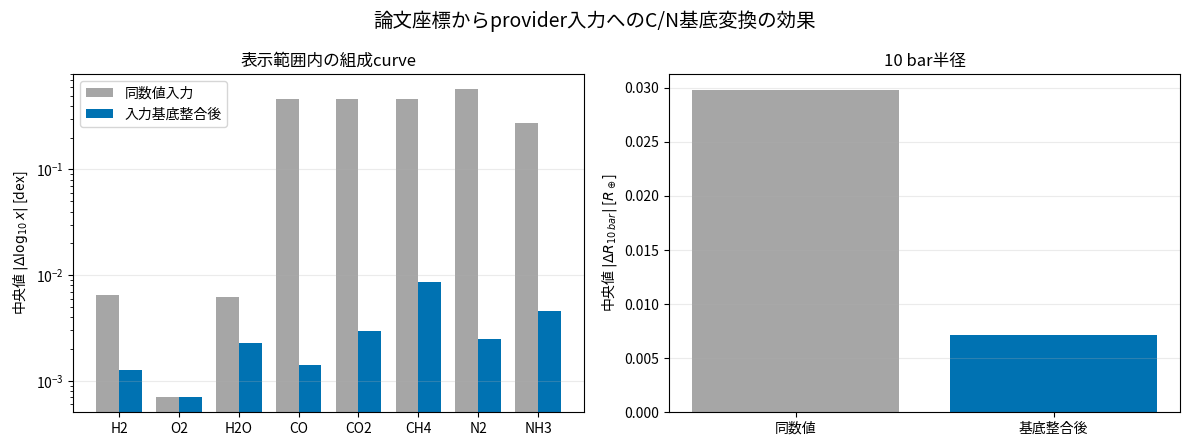

In [6]:
plot_basis_mapping_effect(COMPARISON, language="ja")
plt.show()

同数値runでは表示範囲内curveのmedian absolute差が $P_{melt}$ 気相0.342 dex、10 bar気相0.350 dexだった。基底整合後、pressure sweepのN₂/NH₃を除く1073 **matched plotted-trace samples**（独立な物理点数ではない）ではmedian 0.00239 dex、90 percentile 0.02952 dexとなる。surface H/O/C sampleはすべてpaper half-stroke内だが、10 barではCOのmedianが0.03586 dexで、CO₂/CH₄等にも端部outlierが残る。従って典型的trendは図の線幅scaleまで改善するが、全traceの数値的一致を意味しない。rawの主要offsetがroot不収束ではなくC/N入力基底の同一視と強く関係することは明瞭である。

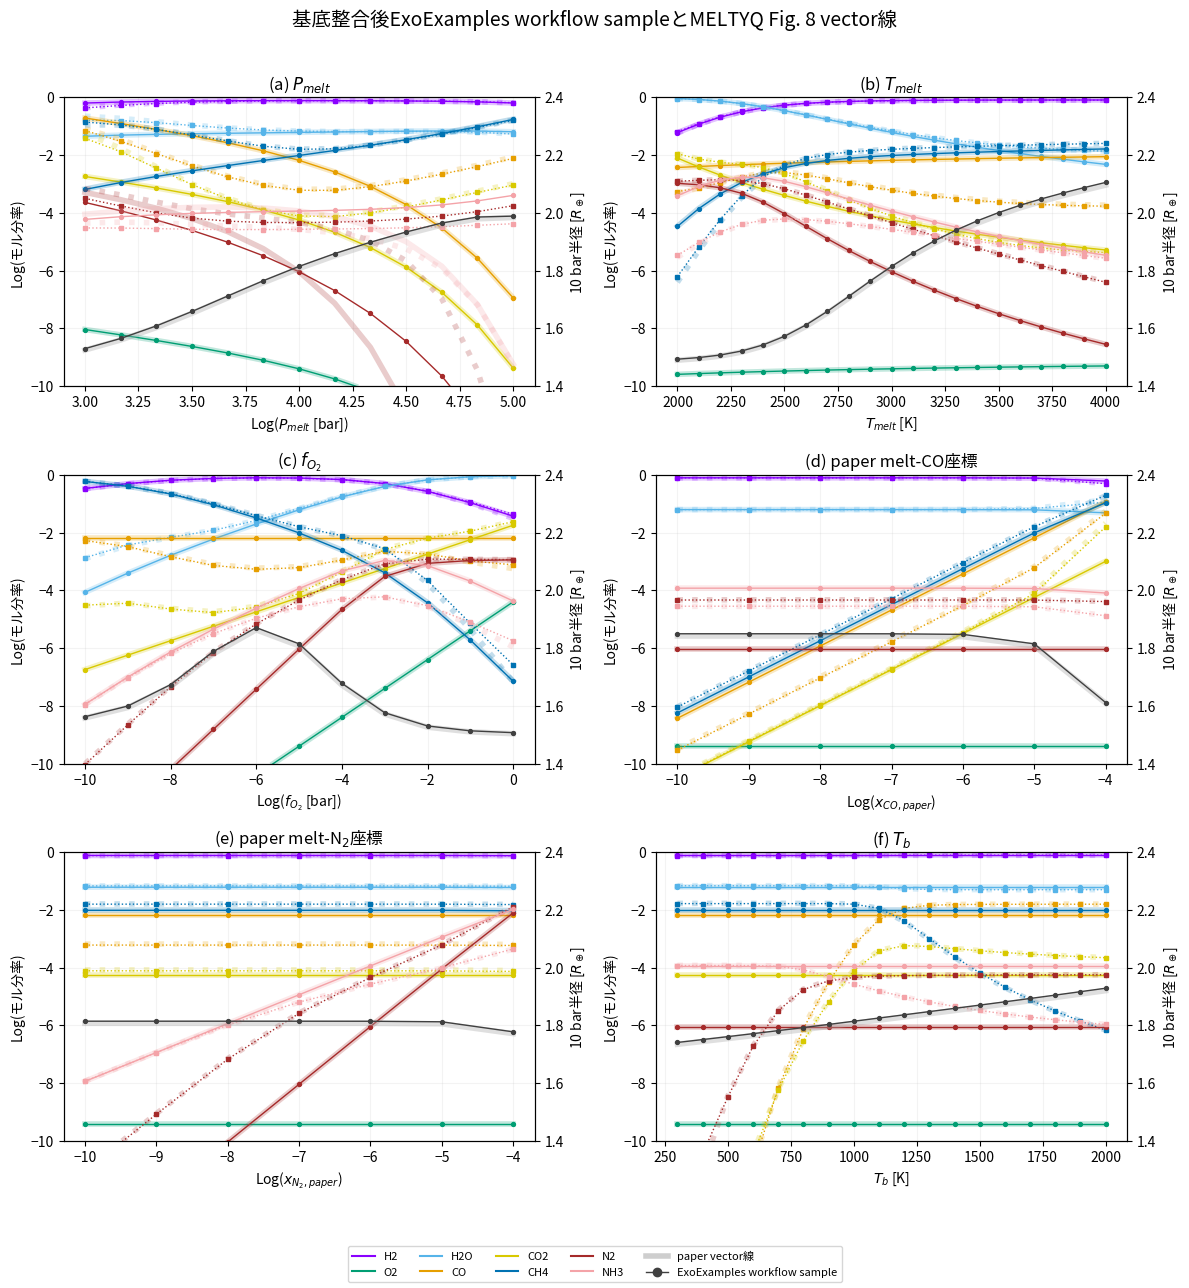

In [7]:
plot_basis_aligned_overlay(COMPARISON, REFERENCE, language="ja")
plt.show()

太い半透明線がpublished vector stroke、細線とmarkerがbasis-aligned ExoExamples workflow sampleである。solid/circleは$P_{melt}$気相、dotted/squareは10 bar気相。重なりは図上のtrend整合を直接示すが、線幅はuncertaintyではない。panel (a)の高圧Nと、いくつかの10 bar traceの小差はoverlayでも確認できる。

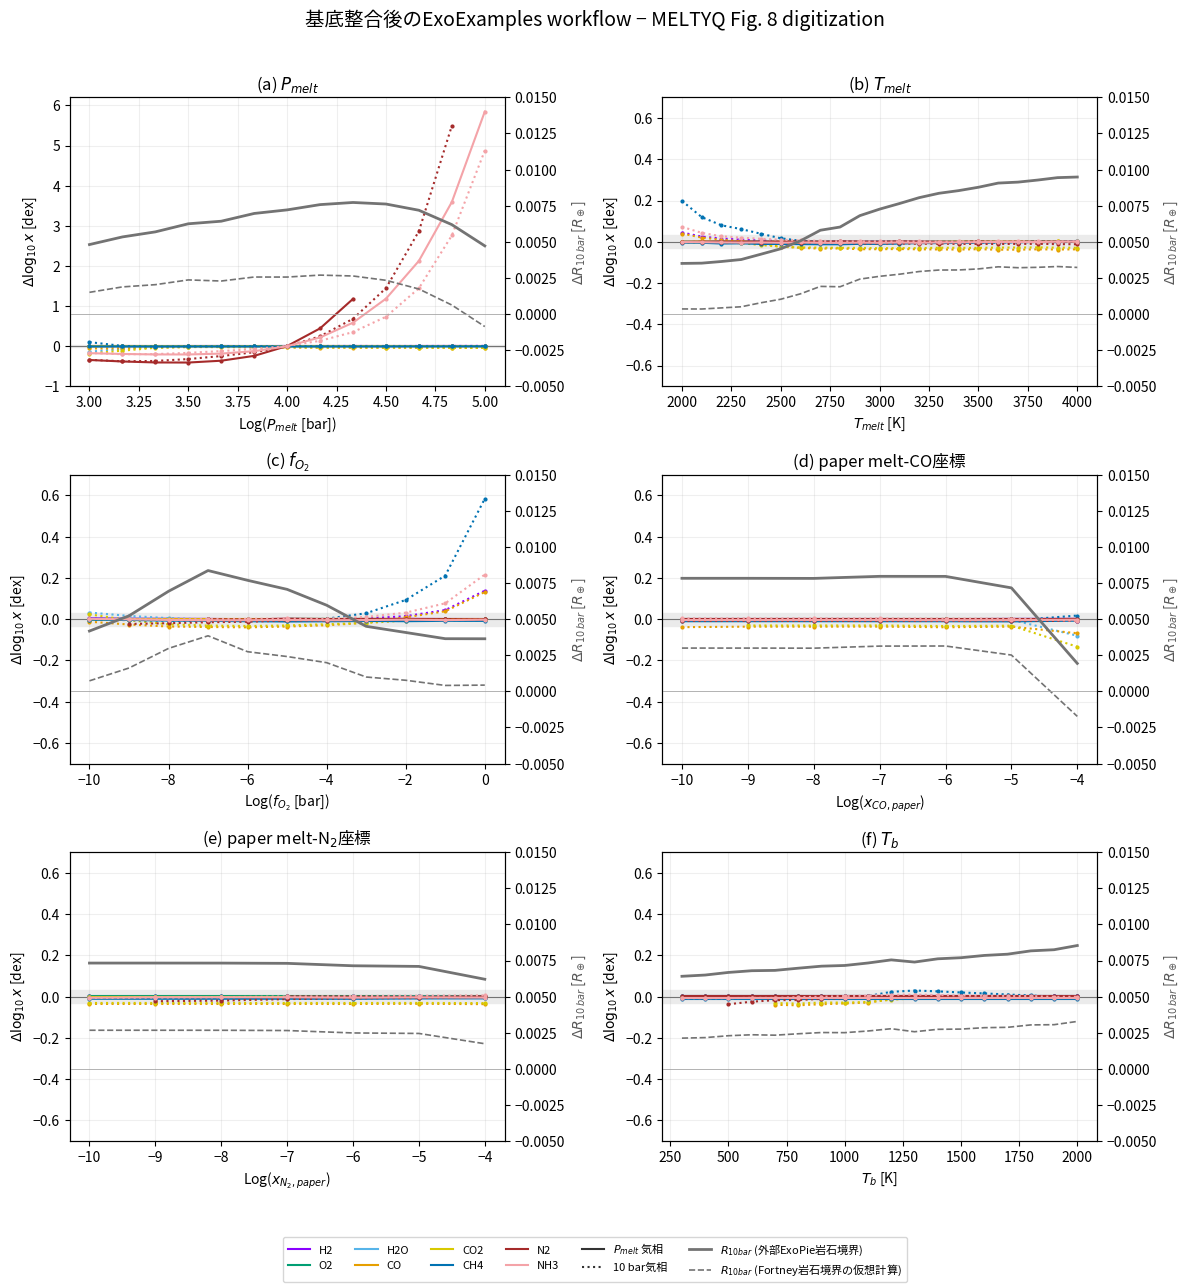

In [8]:
plot_basis_aligned_differences(COMPARISON, language="ja")
plt.show()

灰色bandは論文組成線の半線幅を視覚的scaleとして示す（uncertaintyではない）。colored lineは `current ExoExamples workflow − paper vector centerline`、右軸のgray solidは外部ExoPie rocky boundaryでの半径差、gray dashedは同じ密度profileでFortney rocky boundaryへ置換した仮想半径差である。大部分の組成差は0付近に集まるが、panel (a) のN₂/NH₃だけは高圧で数dex離れる。

### 7.3 Appendixの圧力単位と高圧N式の差

MELTYQ AppendixのCO溶解度則は圧力をGPaと表示するが、一次文献とExoGibbs実装はbarを使う。逆にCH₄溶解度則はAppendixがbarと表示するのに対し、一次文献とExoGibbsはGPaを使う。本書の式と実装はどちらも一次文献側に統一しており、これらはruntimeのunit-conversion bugではない。ただし未公開author codeがどの表記を採用したかは確定できない。

MELTYQ Appendix A6はN solubility指数を $5908P_{melt}/T$ とtypesetし、published Fig. 8の高圧N curveはこのlinear-$P$形と整合する。一方、一次文献 [Dasgupta et al. (2022), Eq. 10](https://doi.org/10.1016/j.gca.2022.09.012) は $5908\sqrt{P_{melt}}/T$ であり、ExoGibbsは一次文献に整合する平方根形を採用する。baselineの1 GPa付近では差が小さいが、10 GPaではNH₃@$P_{melt}$ がpaper digitization −9.240 dex、ExoGibbs −3.393 dexとなり、+5.847 dex離れる。この観測はformula variantと整合し、solver failureではないが、未公開author codeの実装を断定するものではない。

一次文献に従う現行ExoGibbs defaultをpublished formula/implementation variantへ変更すべきではない。Figure 8をpixel-levelでlegacy再現する要件が生じた場合のみ、ExoGibbs側に明示的opt-in compatibility modeが必要になる。

### 7.4 半径差

基底整合後も全77 panel entriesで現ExoExamples workflowの10 bar半径はpaperより大きく、差は +0.00194〜+0.00948 $R_\oplus$、median +0.00716 $R_\oplus$。MELTYQが使うcorrected Fortney et al. relationでは4 $M_\oplus$, iron 33%の**岩石惑星半径**は1.44231987 $R_\oplus$、外部ExoPieの$R_{rock}$は1.44527308 $R_\oplus$で、下端境界は0.002953 $R_\oplus$異なる。どちらもmetal core半径ではない。$g\propto r^{-2}$なので、この値を10 bar差へそのまま足してはいけない。§3.7の同じ$I_\rho$を保つcounterfactualは

$$R_{10}^{Fortney}=\left[(R_{rock}^{Fortney})^{-1}-I_\rho\right]^{-1}$$

であり、Fortney rocky boundaryへ置換すると10 bar半径はmedian 0.004653 $R_\oplus$低下する。paperとの差はmin −0.001732、median +0.002512、max +0.003850 $R_\oplus$となり、70/77 samplesがpaper half-stroke内に入る。この同一density-profile仮想計算ではrocky lower-boundary prescriptionがoffsetの主要部分を説明するが、残差はEOS/structure差とdigitizationをまだ分離していない。

## 8. 何が一致し、何が未確定か

| 項目 | 現時点の判断 |
|---|---|
| H/O/C gas chemistry | surfaceは全matched samplesがpaper half-stroke内。10 barは典型的に線幅scaleだがCOの小さい系統差と端部outlierが残る。著者数値との厳密一致は未検証。 |
| N chemistry | 1 GPa baselineとN-input sweepは典型的に近い。$P_{melt}$ sweepはpublished linear-$P$形とExoGibbs $\sqrt P$形のvariantに整合する差を示す。 |
| 10 bar radius | curve形は近く、正offsetが残る。Fortney rocky-boundary仮想計算でoffsetの主要部分が縮む。 |
| 収束性 | 両runの全72 unique pointsでouter/inner/profile/base flagがtrue。未収束は比較を妨げていない。 |
| sampling | vector artから推定。論文の生成gridそのものとは保証できない。 |
| thermochemistry | temperature依存は確認したが、probeだけで全温度域のaccuracyは保証しない。 |
| deep discretization | 現行64 layers。論文のlayer数は非公開。 |
| 物理calibration範囲 | $T_{melt}=4000$ K、$T_b=300$ K、$P_{melt}=10$ GPaを含む感度端ではEOS/solubility lawをcalibration範囲外へ外挿しうる。図の再現は外挿predictionの物理validationではない。 |
| upper atmosphere / spectrum / retrieval | このFigure 8 exampleには含まれない。 |

入力基底alignmentはExoExamplesのapplication責務なのでExoFamily修正は不要。一次文献に従うN lawもdefault修正不要である。published-A6互換性を将来要求する場合だけ、ExoGibbsに明示的variantを追加する。

## 9. 再生成手順

model環境には`pandas`, `matplotlib`, `ipykernel`、ExoFamily provider依存と外部ExoPie、変換環境には`jupyter-nbconvert`とPandocが必要である。日本語図には`Noto Sans CJK JP`を使う。`python3`という汎用kernel名は別環境を指しうるため、model環境のabsolute executableを持つ専用kernelを一度登録し、repository rootから実行する。

```console
python -m ipykernel install --user --name exoexamples --display-name "Python (ExoExamples)"
JAX_PLATFORMS=cpu jupyter-nbconvert --to notebook --execute --inplace docs/ja/meltyq/meltyq_figure8_forward_comparison_ja.ipynb --ExecutePreprocessor.timeout=900 --ExecutePreprocessor.kernel_name=exoexamples
jupyter-nbconvert --to rst --no-prompt --template-file=docs/meltyq/rst_with_cell_spacing.j2 --output-dir docs/ja/meltyq docs/ja/meltyq/meltyq_figure8_forward_comparison_ja.ipynb
```

論文vector referenceを再抽出する場合は、arXiv sourceを展開して次を実行する。`pdftocairo` が必要である。

```console
python docs/meltyq/extract_meltyq_figure8_reference.py /path/to/meltyq-source docs/meltyq/data/meltyq_figure8_vector_reference.csv
```

計算結果metadataはExoExamples計算source、importされたruntime version、ExoGibbs・ExoEOS・ExoJAX・外部ExoPieのPython source inventory、およびExoPieのpackaged mass–radius data tableのfingerprintに加え、生成時刻と生成済みCSV/PNGのSHA-256・sizeを記録する。従ってeditable installのPython変更、ExoPie data tableの変更、生成物の変更・破損も不一致として自動再生成される。それ以外の非Python asset、native library、backend環境の差はscope外なので、必要なら `EXOEXAMPLES_FORCE_MELTYQ_DOCUMENT_RESULTS=1` をnotebook実行commandの前に置く。再生成commandはcross-platform基準値のためCPUを明示する。JAX executableは既定で `.cache/jax` に保存され、`JAX_COMPILATION_CACHE_DIR` が設定済みならその値を尊重する。

## 10. 結論

このexampleはExoExamplesがExoFamily providerのpublic境界と外部ExoPieのrocky lower boundaryをapplication側で接続し、magma surface gas、deep equilibrium、10 bar gas、density、radiusを一つのforward mapとして評価する。現在の全点は収束し、JIT再利用も成立している。論文Fig. 8との単純比較を妨げていた第一要因はCO/N入力基底であり、operational mapping後はsurface H/O/Cの全matched samplesと、10 barを含む典型的trendがpublished stroke scaleまで近づく。一方、10 barの一部outlier、高圧Nのformula variantと整合する差、rocky lower-boundary prescriptionで大きく縮むradius offsetが残る。従って現段階で言えるのは「現ExoExamples workflowがMELTYQ Fig. 8の大部分のforward trendを再現し、差の所在をinterface・model variant単位で分離できた」であり、「論文の非公開数値を完全再現した」ではない。

### References

- Ito, Y. & Changeat, Q. 2026, *The Astrophysical Journal*, 1006:37, [doi:10.3847/1538-4357/ae6917](https://doi.org/10.3847/1538-4357/ae6917), CC BY 4.0.
- Plotnykov, M. & Valencia, D. 2024, *Observation uncertainty effects on the precision of interior planetary parameters*, *Monthly Notices of the Royal Astronomical Society*, 530, 3488--3499, [doi:10.1093/mnras/stae993](https://doi.org/10.1093/mnras/stae993); software: [ExoPie GitHub repository](https://github.com/mplotnyko/exopie/).
- Zhang, C. & Duan, Z. 2009, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2009.01.021](https://doi.org/10.1016/j.gca.2009.01.021).
- Chabrier, G. & Debras, F. 2021, *The Astrophysical Journal*, [doi:10.3847/1538-4357/abfc48](https://doi.org/10.3847/1538-4357/abfc48).
- Hirschmann et al. 2012, *Earth and Planetary Science Letters*, [doi:10.1016/j.epsl.2012.06.031](https://doi.org/10.1016/j.epsl.2012.06.031).
- Hirschmann, M. M. 2021, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2021.08.039](https://doi.org/10.1016/j.gca.2021.08.039).
- Lichtenberg et al. 2021, *Journal of Geophysical Research: Planets*, [doi:10.1029/2020JE006711](https://doi.org/10.1029/2020JE006711).
- Yoshioka et al. 2019, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2019.06.007](https://doi.org/10.1016/j.gca.2019.06.007).
- Ardia et al. 2013, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2013.03.028](https://doi.org/10.1016/j.gca.2013.03.028).
- Dasgupta et al. 2022, *Geochimica et Cosmochimica Acta*, [doi:10.1016/j.gca.2022.09.012](https://doi.org/10.1016/j.gca.2022.09.012).
- Fortney, Marley & Barnes 2007, [doi:10.1086/512120](https://doi.org/10.1086/512120); corrected coefficients in the [erratum](https://doi.org/10.1086/521435).